# CC3092 – Deep Learning · Laboratorio 7
## Forecasting de temperatura de aceite (ETTh1) con LSTM y Transformer desde cero

**Integrantes:** _completar_

Objetivo: predecir `OT` (Oil Temperature) a $h=24$ y $h=48$ horas con una ventana de $L=96$ horas, usando un LSTM many-to-one y un Transformer encoder implementados con tensores PyTorch puros (sin `nn.LSTM`, `nn.MultiheadAttention` ni `nn.LayerNorm`).

Notas de ejecucion:
- Todo corre en CPU. Con el LSTM manual medimos 3.9 s/epoca en CPU vs 10.4 s/epoca en CUDA (RTX 3050): el loop paso a paso con matrices chicas no aprovecha la GPU.
- Semilla fija (`SEED = 42`) para que los resultados sean reproducibles.

In [1]:
import math
import urllib.request

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 42
L = 96                      # 4 dias de historia horaria
HORIZONTES = (24, 48)
EPOCAS, BATCH, LR = 20, 64, 1e-3   # lr default de adam, el enunciado no lo fija

torch.manual_seed(SEED)
np.random.seed(SEED)
print(f"PyTorch: {torch.__version__}")

PyTorch: 2.11.0+cu128


---
# Task 1 (Entrega parcial)
## Task 1.1 – Descarga y preprocesamiento

In [2]:
URL = ("https://raw.githubusercontent.com/zhouhaoyi/"
       "ETDataset/main/ETT-small/ETTh1.csv")
urllib.request.urlretrieve(URL, "ETTh1.csv")

data = np.genfromtxt("ETTh1.csv", delimiter=",", skip_header=1)
OT  = data[:, -1].astype(np.float32)   # Oil Temperature: columna objetivo
ALL = data[:, 1:].astype(np.float32)   # 7 variables (6 de carga + OT), no se usan porque los modelos son univariados

print(f"filas: {len(OT)}, NaN: {int(np.isnan(data[:, 1:]).sum())}")

filas: 17420, NaN: 0


**a–b. Normalizacion y split temporal.** Se usa $z_t = (x_t - \mu)/\sigma$. $\mu$ y $\sigma$ se calculan **solo con el bloque de entrenamiento** para que validacion y prueba no filtren informacion al modelo (con las estadisticas de toda la serie los asserts tambien pasan, pero eso seria data leakage). El split es 60/20/20 en bloques contiguos, sin mezclar.

In [3]:
# cortes del split temporal 60/20/20, bloques contiguos sin shuffle
n = len(OT)
n_tr, n_vl = int(0.6 * n), int(0.2 * n)

# mu y sigma solo de train, asi val y test no le pasan info al modelo
mu, sigma = OT[:n_tr].mean(), OT[:n_tr].std()
OT_norm = torch.from_numpy((OT - mu) / sigma)   # z_t = (x_t - mu) / sigma

OT_train = OT_norm[:n_tr]
OT_val   = OT_norm[n_tr:n_tr + n_vl]
OT_test  = OT_norm[n_tr + n_vl:]

print(f"mu = {mu:.4f}, sigma = {sigma:.4f}")
for nombre, s in (("train", OT_train), ("val", OT_val), ("test", OT_test)):
    print(f"{nombre:<5}: {len(s):5d} pasos, media = {s.mean():+.3f}, std = {s.std():.3f}")

mu = 17.2925, sigma = 8.5137
train: 10452 pasos, media = +0.000, std = 1.000
val  :  3484 pasos, media = -1.206, std = 0.516
test :  3484 pasos, media = -1.124, std = 0.405


**c. Ventanas.** Cada ejemplo es $X^{(t)} = (x_{t-L+1}, \dots, x_t)$, $y^{(t)} = x_{t+H}$. Con una serie de largo $T$ salen $N = T - L - H + 1$ ventanas.

In [4]:
def make_windows(series, L, H):
    # X^(t) = (x_{t-L+1}, ..., x_t)  ->  y^(t) = x_{t+H}
    series = torch.as_tensor(series)
    N = len(series) - L - H + 1
    X = series.unfold(0, L, 1)[:N]     # cada fila es una ventana de L pasos seguidos
    y = series[L - 1 + H:]             # el valor que esta H pasos despues del final de cada ventana
    return X.contiguous(), y.clone()


splits = {"tr": OT_train, "vl": OT_val, "te": OT_test}
ventanas = {H: {k: make_windows(s, L, H) for k, s in splits.items()} for H in HORIZONTES}

# nombres que piden las celdas de verificacion
X_tr_24, y_tr_24 = ventanas[24]["tr"]
X_vl_24, y_vl_24 = ventanas[24]["vl"]

for H in HORIZONTES:
    for k, (X, y) in ventanas[H].items():
        print(f"H={H} {k}: X {tuple(X.shape)}, y {tuple(y.shape)}")

H=24 tr: X (10333, 96), y (10333,)
H=24 vl: X (3365, 96), y (3365,)
H=24 te: X (3365, 96), y (3365,)
H=48 tr: X (10309, 96), y (10309,)
H=48 vl: X (3341, 96), y (3341,)
H=48 te: X (3341, 96), y (3341,)


## Task 1.2 – Funcion de autocorrelacion (ACF)

$$\rho(k) = \frac{\frac{1}{N-k}\sum_{t=k}^{N-1}(x_t - \bar{x})(x_{t-k} - \bar{x})}{\frac{1}{N}\sum_{t=0}^{N-1}(x_t - \bar{x})^2}$$

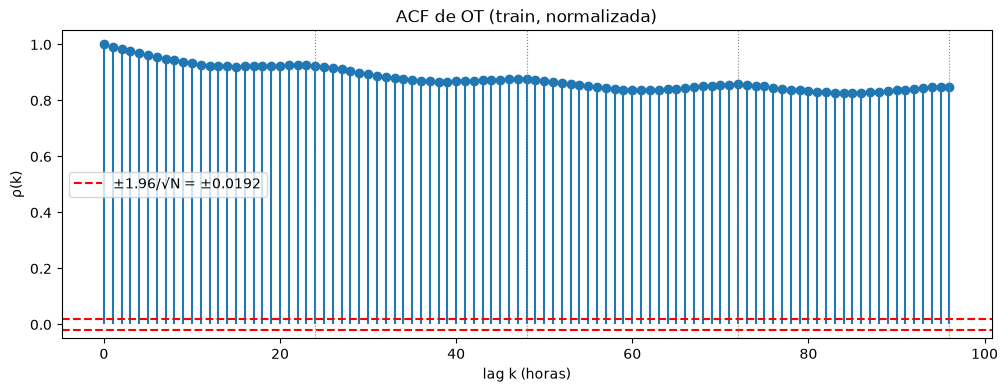

In [5]:
def acf_manual(series, max_lag):
    x = np.asarray(series, dtype=np.float64)
    N = len(x)
    d = x - x.mean()                   # x_t - x_barra
    den = (d @ d) / N                  # (1/N) * sum (x_t - x_barra)^2
    # numerador: (1/(N-k)) * sum_{t=k}^{N-1} (x_t - x_barra)(x_{t-k} - x_barra)
    return np.array([(d[k:] @ d[:N - k]) / (N - k) / den for k in range(max_lag + 1)])


acf_tr = acf_manual(OT_train.numpy(), 96)
banda = 1.96 / np.sqrt(len(OT_train))   # intervalo de confianza al 95%

fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(range(len(acf_tr)), acf_tr, basefmt=" ")
ax.axhline(banda, color="r", ls="--", label=f"±1.96/√N = ±{banda:.4f}")
ax.axhline(-banda, color="r", ls="--")
for k in (24, 48, 72, 96):
    ax.axvline(k, color="gray", ls=":", lw=0.8)
ax.set(xlabel="lag k (horas)", ylabel="ρ(k)", title="ACF de OT (train, normalizada)")
ax.legend()
plt.show()

In [6]:
# un pico local es un lag mas alto que sus dos vecinos
picos = [k for k in range(1, len(acf_tr) - 1) if acf_tr[k - 1] < acf_tr[k] > acf_tr[k + 1]]
picos = sorted(picos, key=lambda k: -acf_tr[k])

print(f"maximo despues de lag 0 (sin ser pico): lag 1 = {acf_tr[1]:.4f}")
print("picos locales (de mayor a menor):")
for k in picos:
    print(f"  lag {k:2d}: ρ = {acf_tr[k]:.4f}")
print("valores de referencia:")
for k in (1, 12, 22, 24, 36, 47, 48, 72, 96):
    print(f"  ρ({k:2d}) = {acf_tr[k]:.4f}")
print(f"banda 95%: ±{banda:.4f}")

maximo despues de lag 0 (sin ser pico): lag 1 = 0.9923
picos locales (de mayor a menor):
  lag 22: ρ = 0.9262
  lag 47: ρ = 0.8770
  lag 72: ρ = 0.8572
valores de referencia:
  ρ( 1) = 0.9923
  ρ(12) = 0.9250
  ρ(22) = 0.9262
  ρ(24) = 0.9250
  ρ(36) = 0.8695
  ρ(47) = 0.8770
  ρ(48) = 0.8763
  ρ(72) = 0.8572
  ρ(96) = 0.8489
banda 95%: ±0.0192


**1.2 a. Segundo pico mas alto e interpretacion**

El valor mas alto despues de lag 0 es lag 1 ($\rho(1)=0.9923$), pero no es un pico: es el inicio del decaimiento monotono. El pico local mas alto es **lag 22** ($\rho=0.9262$), practicamente empatado con lag 24 ($\rho(24)=0.9250$). Le siguen los picos en **lag 47** ($0.8770$) y **lag 72** ($0.8572$), separados ~24-25 h entre si.

Interpretacion: la temperatura del aceite tiene un **ciclo diario** (carga electrica y temperatura ambiente que se repiten cada dia) montado sobre una componente lenta muy persistente. El pico cae en 22 y no exactamente en 24 porque la ACF es casi plana en esa zona ($\rho(12)=0.9250$, $\rho(22)=0.9262$, $\rho(24)=0.9250$, diferencias < 0.002): la oscilacion diaria es pequena frente a la persistencia del nivel, asi que pequenos corrimientos de fase mueven el maximo local un par de horas. La secuencia 22 → 47 → 72 confirma la periodicidad de ~1 dia.

**1.2 b. ¿Es L = 96 apropiado?**

Todos los valores de la ACF hasta lag 96 estan muy por encima de la banda de confianza ($\pm 0.0192$); el minimo es $\rho(96)=0.8489$. La serie es muy persistente y la ACF no tiene un punto de corte a partir del cual la historia deje de estar correlacionada, asi que el criterio para elegir $L$ tiene que salir de la estructura periodica.

- $L=96$ cubre **4 ciclos diarios completos** e incluye los tres picos diarios (22, 47, 72) mas el lag 96, asi que el modelo puede ver la misma hora del dia en varios dias previos.
- Un $L$ mucho **menor** (< 24) perderia el ciclo diario completo; con $L=48$ solo quedarian 2 ciclos.
- Un $L$ **mayor** agregaria sobre todo informacion redundante: de lag 47 a lag 96 la ACF solo baja de $0.877$ a $0.849$, o sea los lags extra estan casi igual de correlacionados (colineales). Ademas alarga la cadena del LSTM (ya son 96 pasos) y el costo $O(L^2)$ de la atencion.

Conclusion: $L=96$ es apropiado. Seria razonable explorar $L=168$ (ciclo semanal), pero este correlograma, que llega hasta 96, no da evidencia para justificarlo.

### Verificacion Task 1

In [7]:
# Ejecute esta celda para verificar su implementacion
_ok = True

# V1: split temporal correcto
assert len(OT_train) + len(OT_val) + len(OT_test) == len(OT_norm), \
    "Los splits no cubren toda la serie"
assert OT_train[-1] != OT_val[0], \
    "El ultimo valor de train no debe ser el primero de val"

# V2: ventanas correctas
assert X_tr_24.shape[1] == 96, f"Ventana incorrecta: {X_tr_24.shape[1]}"
assert y_tr_24.shape[0] == X_tr_24.shape[0], "X e y tienen distinto numero de ejemplos"

# V3: ACF en lag 24 (estacionalidad diaria esperada)
acf_lag24 = acf_manual(OT_train.numpy(), 48)[24]
assert 0.875 < acf_lag24 < 0.975, \
    f"ACF lag 24 fuera de rango: {acf_lag24:.4f} (esperado en [0.875, 0.975])"

# V4: baseline naive
naive_mae = torch.abs(y_vl_24 - X_vl_24[:, -1]).mean().item()
assert 0.15 < naive_mae < 0.25, \
    f"Naive MAE fuera de rango: {naive_mae:.4f} (esperado en [0.15, 0.25])"

print(f"Task 1: CORRECTO (ACF lag24={acf_lag24:.4f}, naive_mae={naive_mae:.4f})")

Task 1: CORRECTO (ACF lag24=0.9250, naive_mae=0.2009)


---
# Task 2 (Entrega parcial)
## Task 2.1 – LSTMForecaster manual

Por cada paso $t$:
$$[\,i;f;g;o\,] = x_t W_x^\top + h_{t-1} W_h^\top + b,\quad i,f,o = \sigma(\cdot),\ g = \tanh(\cdot)$$
$$c_t = f \odot c_{t-1} + i \odot g,\qquad h_t = o \odot \tanh(c_t),\qquad \hat{y} = h_T W_{out}^\top + b_{out}$$

In [8]:
class LSTMForecaster(nn.Module):
    def __init__(self, d_in, d_h):
        super().__init__()
        self.d_h = d_h
        k = 1 / math.sqrt(d_h)   # misma escala de init que usa pytorch en sus rnn
        # las 4 compuertas (i, f, g, o) van apiladas en filas
        self.Wx = nn.Parameter(torch.empty(4 * d_h, d_in).uniform_(-k, k))   # (4*d_h, d_in)
        self.Wh = nn.Parameter(torch.empty(4 * d_h, d_h).uniform_(-k, k))    # (4*d_h, d_h)
        self.b = nn.Parameter(torch.zeros(4 * d_h))                          # (4*d_h,)
        self.W_out = nn.Parameter(torch.empty(1, d_h).uniform_(-k, k))       # (1, d_h)
        self.b_out = nn.Parameter(torch.zeros(1))                            # (1,)

    def forward(self, x):
        B, L = x.shape
        x = x.unsqueeze(-1)                       # (B, L, 1), un escalar por paso
        h = x.new_zeros(B, self.d_h)              # h_0 = 0
        c = x.new_zeros(B, self.d_h)              # c_0 = 0
        for t in range(L):
            gates = x[:, t, :] @ self.Wx.T + h @ self.Wh.T + self.b
            i, f, g, o = gates.chunk(4, dim=-1)   # cada una de tamano d_h
            i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
            g = torch.tanh(g)
            c = f * c + i * g                     # c_t = f*c_{t-1} + i*g
            h = o * torch.tanh(c)                 # h_t = o*tanh(c_t)
        pred = h @ self.W_out.T + self.b_out      # solo se usa h_T (many-to-one)
        return pred.squeeze(-1)


print(LSTMForecaster(d_in=1, d_h=32)(torch.randn(8, L)).shape)

torch.Size([8])

## Task 2.2 – Entrenamiento y evaluacion

**Cambio de nivel entre splits.** La salida del Task 1.1 muestra que validacion y prueba estan en promedio ~1.2 desviaciones por debajo de train y con la mitad de variabilidad (periodo mas frio y estable). Un modelo que predice el **nivel absoluto** aprende el rango de train y se equivoca en val. En una corrida preliminar sin transformar (no incluida) el LSTM dio ratio ≈ 1.37 vs naive y no pasaba la verificacion; normalizar con toda la serie (≈1.26) o subir el lr (≈1.25) no alcanzaba.

Solucion: trabajar **relativo al ultimo valor observado** $x_t$ (la misma idea que usa NLinear sobre ETT). La red ve $	ilde{X} = X - x_t$ y aprende $	ilde{y} = y - x_t$; la prediccion final es $\hat{y} = x_t + f(	ilde{X})$. Las clases de los modelos no cambian (el enunciado se respeta); la transformacion vive en `centrar`, `entrenar_por_horizonte` y `predecir`, y aplica igual a LSTM y Transformer.

Utilidades compartidas (tambien las usa el Transformer en el Task 3):
- `centrar`: resta $x_t$ a cada ventana.
- `entrenar`: minibatches de 64, Adam, MSE. Se barajan las **ventanas** de train (son ejemplos independientes); el split sigue siendo contiguo.
- `predecir`: inferencia sin gradiente; devuelve $x_t + f(	ilde{X})$, o sea ya en escala absoluta.
- `metricas`: MAE, RMSE y ratio vs naive, en escala normalizada y en °C (multiplicando por $\sigma$).
- Baseline naive: $\hat{y}^{(t)} = x_t$, el ultimo valor de la ventana.

In [9]:
def centrar(X):
    # la ventana queda relativa a su ultimo valor x_t, asi el nivel absoluto deja de importar
    return X - X[:, -1:]


def entrenar(modelo, X, y, epocas=EPOCAS, batch=BATCH, lr=LR):
    # minibatch adam minimizando mse, devuelve la loss promedio de cada epoca
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    gen = torch.Generator().manual_seed(SEED)
    historial = []
    modelo.train()
    for ep in range(epocas):
        perm = torch.randperm(len(X), generator=gen)
        suma = 0.0
        for i in range(0, len(X), batch):
            idx = perm[i:i + batch]
            opt.zero_grad()
            loss = F.mse_loss(modelo(X[idx]), y[idx])   # (1/B) sum (y - y_hat)^2
            loss.backward()
            opt.step()
            suma += loss.item() * len(idx)
        historial.append(suma / len(X))
        if (ep + 1) % 5 == 0:
            print(f"  epoca {ep + 1:2d}/{epocas}  mse_train = {historial[-1]:.4f}")
    return historial


def entrenar_por_horizonte(crear_modelo):
    # un modelo distinto por horizonte, todos con la misma semilla y los mismos datos de train
    modelos, historiales = {}, {}
    for H in HORIZONTES:
        print(f"H = {H}")
        torch.manual_seed(SEED)
        modelos[H] = crear_modelo()
        X, y = ventanas[H]["tr"]
        historiales[H] = entrenar(modelos[H], centrar(X), y - X[:, -1])   # target = y - x_t
    return modelos, historiales


@torch.no_grad()
def predecir(modelo, X, batch=1024):
    modelo.eval()
    delta = torch.cat([modelo(centrar(X[i:i + batch])) for i in range(0, len(X), batch)])
    return X[:, -1] + delta   # y_hat = x_t + f(X - x_t)


def metricas(y, pred, mae_ref):
    mae = (y - pred).abs().mean().item()             # (1/N) sum |y - y_hat|
    rmse = ((y - pred) ** 2).mean().sqrt().item()     # sqrt((1/N) sum (y - y_hat)^2)
    return {"mae": mae, "rmse": rmse, "ratio": mae / mae_ref,
            "mae_C": mae * sigma, "rmse_C": rmse * sigma}


def evaluar(modelos):
    preds = {H: predecir(modelos[H], ventanas[H]["vl"][0]) for H in HORIZONTES}
    res = {H: metricas(ventanas[H]["vl"][1], preds[H], mae_naive[H]) for H in HORIZONTES}
    return preds, res


def imprimir_tabla(filas):
    print(f"{'Modelo':<12}{'H':>4}{'MAE':>9}{'RMSE':>9}{'Ratio':>8}{'MAE °C':>9}{'RMSE °C':>9}")
    for nombre, res in filas:
        for H, m in res.items():
            print(f"{nombre:<12}{H:>4}{m['mae']:>9.4f}{m['rmse']:>9.4f}{m['ratio']:>8.3f}"
                  f"{m['mae_C']:>9.3f}{m['rmse_C']:>9.3f}")


# baseline naive: repetir el ultimo valor observado x_t
mae_naive = {H: (ventanas[H]["vl"][1] - ventanas[H]["vl"][0][:, -1]).abs().mean().item()
             for H in HORIZONTES}
res_naive = {H: metricas(ventanas[H]["vl"][1], ventanas[H]["vl"][0][:, -1], mae_naive[H])
             for H in HORIZONTES}
imprimir_tabla([("Naive", res_naive)])

Modelo         H      MAE     RMSE   Ratio   MAE °C  RMSE °C
Naive         24   0.2009   0.2689   1.000    1.710    2.289
Naive         48   0.2620   0.3380   1.000    2.231    2.878


In [10]:
# a-b. un lstm por horizonte, d_h = 32
lstm, hist_lstm = entrenar_por_horizonte(lambda: LSTMForecaster(d_in=1, d_h=32))

H = 24


  epoca  5/20  mse_train = 0.1502


  epoca 10/20  mse_train = 0.1488


  epoca 15/20  mse_train = 0.1515


  epoca 20/20  mse_train = 0.1522
H = 48


  epoca  5/20  mse_train = 0.2266


  epoca 10/20  mse_train = 0.2229


  epoca 15/20  mse_train = 0.2286


  epoca 20/20  mse_train = 0.2292


In [11]:
# c. metricas en validacion
preds_lstm, res_lstm = evaluar(lstm)
pred_vl_24 = preds_lstm[24]
imprimir_tabla([("LSTM", res_lstm), ("Naive", res_naive)])

Modelo         H      MAE     RMSE   Ratio   MAE °C  RMSE °C
LSTM          24   0.2040   0.2694   1.015    1.736    2.294
LSTM          48   0.2601   0.3331   0.993    2.214    2.836
Naive         24   0.2009   0.2689   1.000    1.710    2.289
Naive         48   0.2620   0.3380   1.000    2.231    2.878


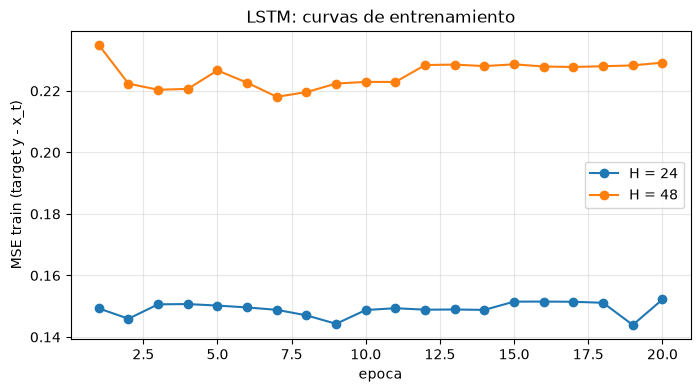

In [12]:
# d. curvas de loss de train de los dos horizontes en la misma figura
fig, ax = plt.subplots(figsize=(8, 4))
for H in HORIZONTES:
    ax.plot(range(1, EPOCAS + 1), hist_lstm[H], marker="o", label=f"H = {H}")
ax.set(xlabel="epoca", ylabel="MSE train (target y - x_t)", title="LSTM: curvas de entrenamiento")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Justificacion de la funcion de perdida (MSE)**

Se uso **MSE**: $\mathcal{L} = \frac{1}{B}\sum_i (y_i - \hat{y}_i)^2$.
- Es regresion sobre un objetivo continuo; bajo el supuesto de error gaussiano, minimizar MSE equivale a maxima verosimilitud.
- Penaliza cuadraticamente los errores grandes. En riesgo termico lo costoso es fallar un pico de temperatura, no un error chico.
- Su gradiente $2(\hat{y}-y)$ es suave y proporcional al error, a diferencia de MAE (gradiente constante y no diferenciable en 0), lo que da un entrenamiento estable con Adam.
- Es coherente con el RMSE que se reporta. El MAE se deja como metrica de evaluacion por ser mas interpretable (en °C).

**Analisis de resultados del LSTM**

- **H=24:** MAE $0.2040$ ($1.736$ °C), RMSE $0.2694$, ratio $1.015$: practicamente igual al naive, un poco peor. Pasa la verificacion (ratio < 1.1).
- **H=48:** MAE $0.2601$ ($2.214$ °C), RMSE $0.3331$, ratio $0.993$: le gana apenas al naive.
- Las curvas de loss son casi planas desde la primera epoca (H=24 entre ~0.144 y 0.152; H=48 entre ~0.218 y 0.235). El LSTM aprende rapido una correccion chica sobre $x_t$ y en 20 epocas no sigue mejorando. H=48 tiene loss mas alta porque el objetivo esta mas lejos.
- El naive es un baseline muy fuerte en una serie tan persistente ($\rho(1)=0.99$). Ademas, sin trabajar relativo a $x_t$ el LSTM no llegaba ni a eso, por el cambio de nivel entre train y val.

### Verificacion Task 2

In [13]:
# Verificar shapes del forward
_model_test = LSTMForecaster(d_in=1, d_h=32)
_x_test = torch.randn(8, 96)
_pred_test = _model_test(_x_test)
assert _pred_test.shape == (8,), \
    f"Shape incorrecto: {_pred_test.shape} (esperado (8,))"

# Verificar que el modelo supera al naive en H=24
mae_lstm_24 = torch.abs(y_vl_24 - pred_vl_24).mean().item()
assert mae_lstm_24 < naive_mae * 1.1, \
    f"LSTM H=24 no supera al naive: {mae_lstm_24:.4f} vs {naive_mae:.4f}"

print(f"Task 2: CORRECTO")
print(f"  LSTM H=24: MAE={mae_lstm_24:.4f}, ratio={mae_lstm_24/naive_mae:.3f}")

Task 2: CORRECTO
  LSTM H=24: MAE=0.2040, ratio=1.015


---
# Task 3 (Entrega final)
## Task 3.1 – Positional encoding

$$\mathrm{PE}(t, 2i) = \sin\!\left(\frac{t}{10000^{2i/d_{model}}}\right),\qquad \mathrm{PE}(t, 2i+1) = \cos\!\left(\frac{t}{10000^{2i/d_{model}}}\right)$$

Cada $x_t$ escalar se proyecta a $\mathbb{R}^{d_{model}}$ con `nn.Linear(1, d_model)` y luego se le suma $\mathrm{PE}(t)$. El PE se registra como *buffer*: viaja con el modelo pero no es aprendible.

In [14]:
def make_pe(max_len, d_model):
    t = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)                      # (L, 1)
    div = 10000 ** (torch.arange(0, d_model, 2, dtype=torch.float32) / d_model)      # 10000^(2i/d_model)
    pe = torch.zeros(max_len, d_model)
    pe[:, 0::2] = torch.sin(t / div)   # dimensiones pares
    pe[:, 1::2] = torch.cos(t / div)   # dimensiones impares
    return pe


_pe = make_pe(L, 32)
print(f"PE shape: {tuple(_pe.shape)}, requires_grad: {_pe.requires_grad}")

PE shape: (96, 32), requires_grad: False


## Task 3.2 – TransformerForecaster con multi-head self-attention manual

$$Q = XW_Q,\ K = XW_K,\ V = XW_V,\qquad \mathrm{head}_h = \mathrm{softmax}\!\left(\frac{Q_h K_h^\top}{\sqrt{d_k}}\right) V_h,\qquad \mathrm{MHA}(X) = [\mathrm{head}_1;\dots;\mathrm{head}_H]\,W_O$$
$$\mathrm{LN}(x) = \gamma \odot \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta,\qquad \mathrm{FFN}(x) = \mathrm{ReLU}(xW_1 + b_1)W_2 + b_2$$

La prediccion sale de la posicion 0, usada como token CLS tal como pide el enunciado. Ojo: no es un token aprendido extra, es el dato mas antiguo de la ventana (lag 96), que agrega informacion del resto via atencion.

In [15]:
def pesos(filas, cols):
    # init tipo xavier: varianza 1/fan_in para que las activaciones no exploten
    return nn.Parameter(torch.randn(filas, cols) / math.sqrt(filas))


def softmax(x, dim=-1):
    # se resta el maximo para que exp no se desborde, no cambia el resultado
    e = torch.exp(x - x.amax(dim=dim, keepdim=True))
    return e / e.sum(dim=dim, keepdim=True)


class TransformerForecaster(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, L):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.L = L
        self.input_proj = nn.Linear(1, d_model)                 # x_t escalar -> R^d_model
        self.register_buffer("PE", make_pe(L, d_model))        # no aprendible
        self.WQ, self.WK = pesos(d_model, d_model), pesos(d_model, d_model)
        self.WV, self.WO = pesos(d_model, d_model), pesos(d_model, d_model)
        self.W1, self.b1 = pesos(d_model, d_ff), nn.Parameter(torch.zeros(d_ff))
        self.W2, self.b2 = pesos(d_ff, d_model), nn.Parameter(torch.zeros(d_model))
        self.gamma1, self.beta1 = nn.Parameter(torch.ones(d_model)), nn.Parameter(torch.zeros(d_model))
        self.gamma2, self.beta2 = nn.Parameter(torch.ones(d_model)), nn.Parameter(torch.zeros(d_model))
        self.W_out = nn.Linear(d_model, 1)

    def layer_norm(self, x, gamma, beta, eps=1e-5):
        media = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return gamma * (x - media) / torch.sqrt(var + eps) + beta

    def multi_head_attention(self, x):
        B, L, _ = x.shape

        def separar(t):
            # (B, L, d_model) -> (B, n_heads, L, d_k)
            return t.view(B, L, self.n_heads, self.d_k).transpose(1, 2)

        Q, K, V = separar(x @ self.WQ), separar(x @ self.WK), separar(x @ self.WV)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)       # (B, n_heads, L, L)
        attn_w = softmax(scores, dim=-1)                              # cada fila suma 1
        out = attn_w @ V                                              # (B, n_heads, L, d_k)
        out = out.transpose(1, 2).reshape(B, L, self.d_model)        # concatenar cabezas
        return out @ self.WO, attn_w

    def feed_forward(self, x):
        return torch.relu(x @ self.W1 + self.b1) @ self.W2 + self.b2

    def forward(self, x, return_attn=False):
        x = self.input_proj(x.unsqueeze(-1)) + self.PE[:x.shape[1]]    # (B, L, d_model)
        att_out, attn_w = self.multi_head_attention(x)
        x = self.layer_norm(x + att_out, self.gamma1, self.beta1)      # add & norm
        x = self.layer_norm(x + self.feed_forward(x), self.gamma2, self.beta2)   # add & norm
        pred = self.W_out(x[:, 0, :]).squeeze(-1)                      # posicion 0 como cls
        return (pred, attn_w) if return_attn else pred

## Task 3.3 – Entrenamiento, evaluacion y mapas de atencion
Mismas condiciones que el LSTM: 20 epocas, Adam, `batch_size=64`, MSE, misma semilla y la misma transformacion relativa a $x_t$.

In [16]:
# a. un transformer por horizonte
trf, hist_trf = entrenar_por_horizonte(lambda: TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=L))

H = 24


  epoca  5/20  mse_train = 0.1300


  epoca 10/20  mse_train = 0.1281


  epoca 15/20  mse_train = 0.1268


  epoca 20/20  mse_train = 0.1249
H = 48


  epoca  5/20  mse_train = 0.1907


  epoca 10/20  mse_train = 0.1887


  epoca 15/20  mse_train = 0.1816


  epoca 20/20  mse_train = 0.1794


In [17]:
# b. metricas en validacion
preds_trf, res_trf = evaluar(trf)
imprimir_tabla([("Transformer", res_trf), ("Naive", res_naive)])

Modelo         H      MAE     RMSE   Ratio   MAE °C  RMSE °C
Transformer   24   0.2066   0.2589   1.029    1.759    2.204
Transformer   48   0.2413   0.3160   0.921    2.055    2.690
Naive         24   0.2009   0.2689   1.000    1.710    2.289
Naive         48   0.2620   0.3380   1.000    2.231    2.878


H=24: indices de validacion usados [0, 841, 1682, 2523, 3364]
H=48: indices de validacion usados [0, 835, 1670, 2505, 3340]


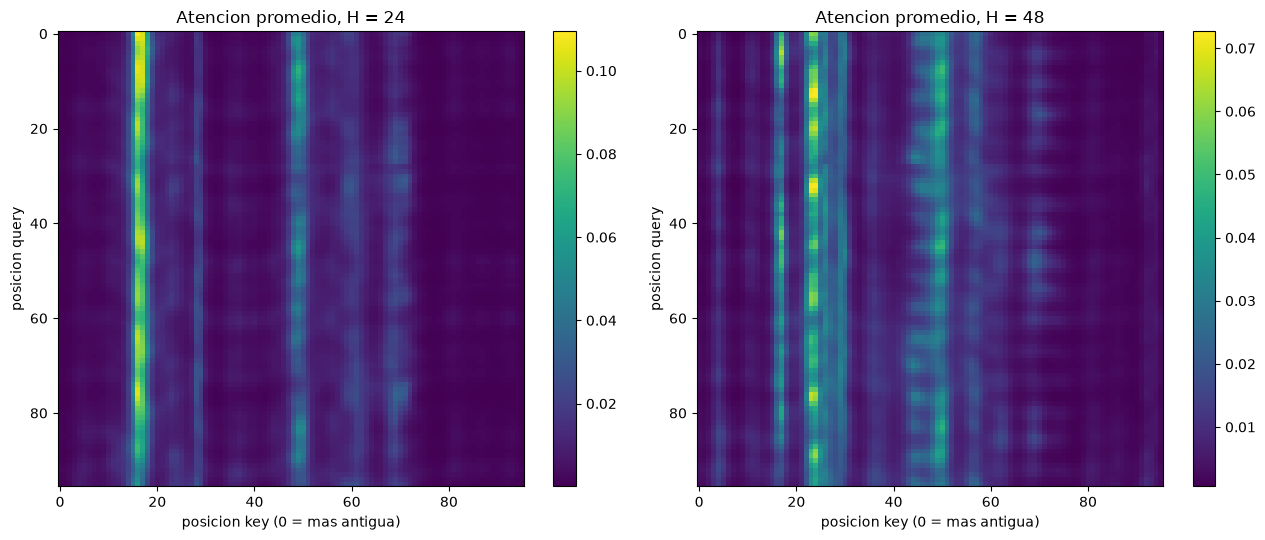

In [18]:
# c. mapas de atencion de 5 ventanas de validacion repartidas en todo el conjunto
attn, idx_ej = {}, {}
for H in HORIZONTES:
    X_vl = ventanas[H]["vl"][0]
    idx_ej[H] = torch.linspace(0, len(X_vl) - 1, 5).long()
    trf[H].eval()
    with torch.no_grad():
        _, attn[H] = trf[H](centrar(X_vl[idx_ej[H]]), return_attn=True)   # (5, n_heads, L, L), misma entrada que en train
    print(f"H={H}: indices de validacion usados {idx_ej[H].tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, H in zip(axes, HORIZONTES):
    mapa = attn[H].mean(dim=(0, 1))                   # promedio sobre 5 ejemplos y 2 cabezas -> (L, L)
    im = ax.imshow(mapa, cmap="viridis", aspect="auto")
    ax.set(title=f"Atencion promedio, H = {H}", xlabel="posicion key (0 = mas antigua)", ylabel="posicion query")
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [19]:
# d. atencion desde la posicion 0 (cls) expresada como lag: posicion p -> lag = L - p
att_lag = {}
for H in HORIZONTES:
    cls = attn[H].mean(dim=(0, 1))[0]      # fila de la query 0, (L,)
    att_lag[H] = cls.flip(0).numpy()       # att_lag[H][k-1] = atencion al lag k
    top = np.argsort(-att_lag[H])[:10] + 1
    print(f"H={H} | top 10 lags desde cls (uniforme = {1 / L:.4f}):")
    for k in top:
        print(f"  lag {k:2d} (posicion {L - k:2d}): {att_lag[H][k - 1]:.4f}")

H=24 | top 10 lags desde cls (uniforme = 0.0104):
  lag 80 (posicion 16): 0.1095
  lag 79 (posicion 17): 0.1033
  lag 78 (posicion 18): 0.0627
  lag 81 (posicion 15): 0.0502
  lag 47 (posicion 49): 0.0473
  lag 48 (posicion 48): 0.0452
  lag 46 (posicion 50): 0.0374
  lag 77 (posicion 19): 0.0261
  lag 49 (posicion 47): 0.0229
  lag 45 (posicion 51): 0.0226
H=48 | top 10 lags desde cls (uniforme = 0.0104):
  lag 73 (posicion 23): 0.0598
  lag 72 (posicion 24): 0.0584
  lag 79 (posicion 17): 0.0458
  lag 74 (posicion 22): 0.0350
  lag 46 (posicion 50): 0.0349
  lag 47 (posicion 49): 0.0339
  lag 70 (posicion 26): 0.0305
  lag 48 (posicion 48): 0.0298
  lag 71 (posicion 25): 0.0294
  lag 45 (posicion 51): 0.0284


**3.3 d. Posiciones con mayor atencion desde CLS**

**H=24:** la atencion desde CLS se concentra en dos bandas:
- **lags 77–81** (posiciones 15–19), con maximo en lag 80 ($0.1095$) y lag 79 ($0.1033$), unas 10 veces el peso uniforme ($1/96=0.0104$);
- **lags 45–49** (posiciones 47–51): lag 47 = $0.0473$, lag 48 = $0.0452$.

**H=48:** las bandas son **lags 70–74** (lag 73 = $0.0598$, lag 72 = $0.0584$), lag 79 ($0.0458$) y **lags 45–48** (~$0.03$–$0.035$).

En ambos modelos los lags recientes (1–24) reciben casi nada (lag 1: $0.0002$ en H=24 y $0.0013$ en H=48). En los heatmaps aparecen **franjas verticales**: todas las queries, no solo la posicion 0, miran las mismas keys. O sea, la atencion la define sobre todo la key (su posicion y contenido) mas que la query.

### Verificacion Task 3

In [20]:
# Verificar shapes
_trf_test = TransformerForecaster(d_model=32, n_heads=2, d_ff=64, L=96)
_x_test = torch.randn(4, 96)
_pred_test, _attn_test = _trf_test(_x_test, return_attn=True)
assert _pred_test.shape == (4,), \
    f"pred shape incorrecto: {_pred_test.shape}"
assert _attn_test.shape == (4, 2, 96, 96), \
    f"attn shape incorrecto: {_attn_test.shape}"

# Verificar que la atencion suma 1 por fila
row_sums = _attn_test[0, 0].sum(-1)
assert torch.allclose(row_sums, torch.ones(96), atol=1e-4), \
    "Los pesos de atencion no suman 1 por fila"

print(f"Task 3: CORRECTO")
print(f"  attn_w shape: {_attn_test.shape}")
print(f"  row sums OK: {row_sums.min().item():.4f} a {row_sums.max().item():.4f}")

Task 3: CORRECTO
  attn_w shape: torch.Size([4, 2, 96, 96])
  row sums OK: 1.0000 a 1.0000


---
# Task 4 (Entrega final)
## Task 4.1 – ACF vs atencion

H=24
   lag      ACF  atencion   origen
     1   0.9923    0.0002   
    22   0.9262    0.0016   pico ACF
    24   0.9250    0.0104   
    47   0.8770    0.0473   top atencion, pico ACF
    48   0.8763    0.0452   
    72   0.8572    0.0079   pico ACF
    78   0.8392    0.0627   top atencion
    79   0.8361    0.1033   top atencion
    80   0.8334    0.1095   top atencion
    81   0.8309    0.0502   top atencion
  spearman(ACF, atencion) sobre lags 1..96: -0.209

H=48
   lag      ACF  atencion   origen
     1   0.9923    0.0013   
    22   0.9262    0.0018   pico ACF
    24   0.9250    0.0032   
    46   0.8761    0.0349   top atencion
    47   0.8770    0.0339   pico ACF
    48   0.8763    0.0298   
    72   0.8572    0.0584   top atencion, pico ACF
    73   0.8557    0.0598   top atencion
    74   0.8532    0.0350   top atencion
    79   0.8361    0.0458   top atencion
  spearman(ACF, atencion) sobre lags 1..96: -0.323



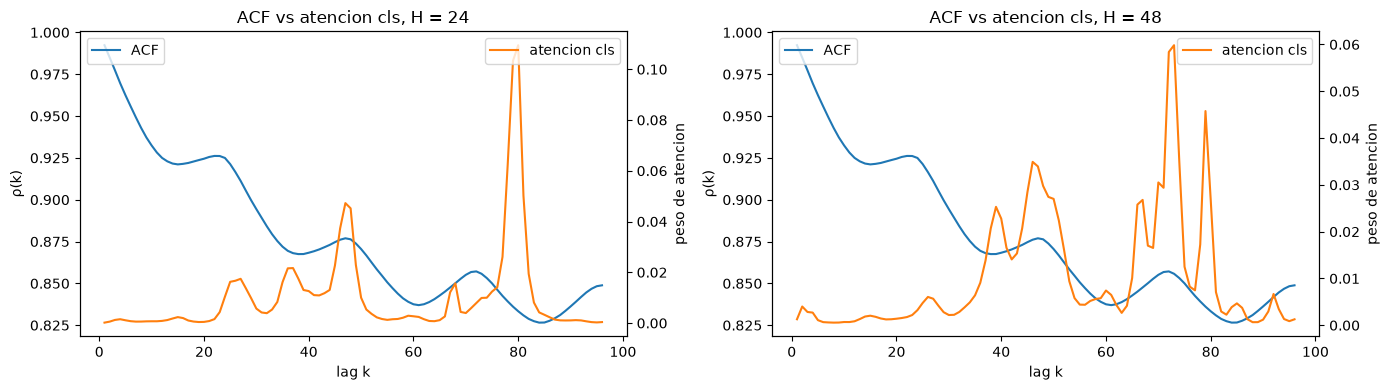

In [21]:
# a. comparar acf(k) con la atencion cls al lag k, en los lags mas relevantes de cada lado
def rangos(v):
    return np.argsort(np.argsort(v))


acf_1a96 = acf_tr[1:]    # acf_1a96[k-1] = rho(k)
for H in HORIZONTES:
    top_att = list(np.argsort(-att_lag[H])[:5] + 1)
    lags = sorted(set(top_att) | set(picos) | {1, 24, 48})
    print(f"H={H}")
    print(f"  {'lag':>4}{'ACF':>9}{'atencion':>10}   origen")
    for k in lags:
        origen = ", ".join(n for n, s in (("top atencion", top_att), ("pico ACF", picos)) if k in s)
        print(f"  {k:>4}{acf_1a96[k - 1]:>9.4f}{att_lag[H][k - 1]:>10.4f}   {origen}")
    # correlacion de spearman = pearson sobre los rangos
    rho_s = np.corrcoef(rangos(acf_1a96), rangos(att_lag[H]))[0, 1]
    print(f"  spearman(ACF, atencion) sobre lags 1..96: {rho_s:.3f}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
lags_eje = np.arange(1, L + 1)
for ax, H in zip(axes, HORIZONTES):
    ax.plot(lags_eje, acf_1a96, color="tab:blue", label="ACF")
    ax.set(xlabel="lag k", ylabel="ρ(k)", title=f"ACF vs atencion cls, H = {H}")
    ax2 = ax.twinx()
    ax2.plot(lags_eje, att_lag[H], color="tab:orange", label="atencion cls")
    ax2.set_ylabel("peso de atencion")
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()

**4.1 a. ¿Coinciden los lags de mayor atencion con los picos de la ACF?**

**Coinciden solo parcialmente.**

| lag | ACF | atencion H=24 | atencion H=48 |
|---|---|---|---|
| 1 | 0.9923 | 0.0002 | 0.0013 |
| 22 (pico ACF) | 0.9262 | 0.0016 | 0.0018 |
| 24 | 0.9250 | 0.0104 | 0.0032 |
| 47 (pico ACF) | 0.8770 | 0.0473 | 0.0339 |
| 48 | 0.8763 | 0.0452 | 0.0298 |
| 72 (pico ACF) | 0.8572 | 0.0079 | 0.0584 |
| 79 | 0.8361 | 0.1033 | 0.0458 |
| 80 | 0.8334 | 0.1095 | (fuera del top, no impreso) |

- **No coinciden en lo global:** la ACF es maxima en los lags cortos y decae, pero la atencion casi no les da peso. La correlacion de Spearman entre ambos perfiles (lags 1..96) es **negativa**: $-0.209$ (H=24) y $-0.323$ (H=48).
- **Si coinciden en los picos diarios lejanos:** lag 47/48 esta en el top de atencion de ambos modelos, y lag 72 es top en H=48.
- La banda de lags 78–81 (el maximo de H=24) no corresponde a ningun pico de la ACF ($\rho \approx 0.83$).

Hipotesis sobre por que difieren:
1. **La ACF mide redundancia, no utilidad.** Lag 1 esta muy correlacionado con $x_t$, pero el modelo ya trabaja relativo a $x_t$ (la entrada centrada hace que los valores recientes esten cerca de 0), asi que los lags recientes casi no aportan informacion nueva. La atencion busca informacion **complementaria**.
2. **Fase respecto al objetivo.** Para predecir $x_{t+H}$ con $H$ multiplo de 24, los lags multiplos de 24 (48, 72) caen justo a la **misma hora del dia que el objetivo**, lo que es coherente con las bandas en 47–48 y 72–73.
3. **El criterio es otro.** El modelo minimiza el MSE del cambio $y - x_t$, no reproduce correlaciones. La banda de lags ~80 podria servir como referencia del nivel de hace ~3 dias, para estimar la tendencia de varios dias ($x_{t-80} - x_t$).
4. **Hay un patron posicional fuerte:** las franjas verticales del heatmap muestran que un modelo de 1 capa con PE aprendio "mirar ciertas posiciones" casi independientemente de la query.

H=24: lag de maxima atencion por ejemplo [80, 80, 79, 80, 79], CV medio entre ejemplos = 0.597
H=48: lag de maxima atencion por ejemplo [72, 73, 80, 79, 67], CV medio entre ejemplos = 0.606


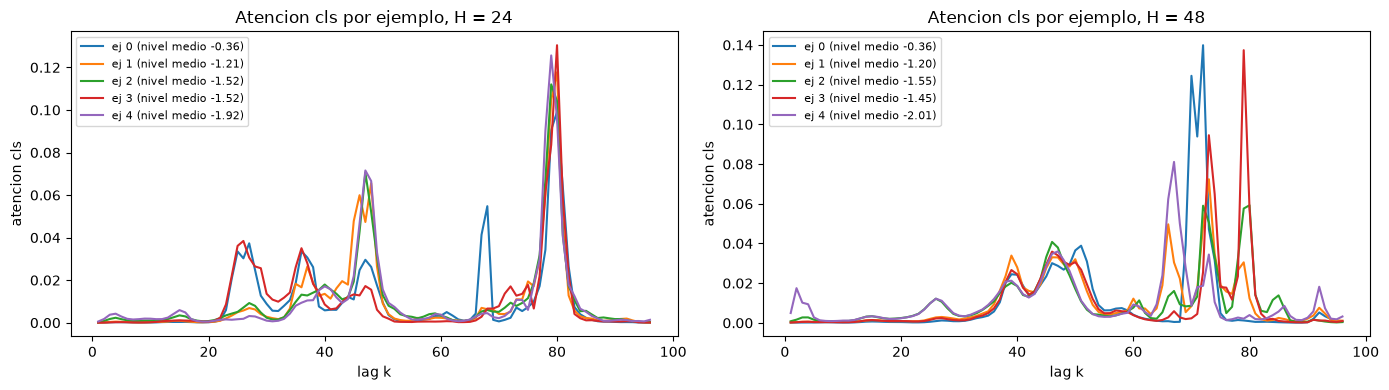

In [22]:
# b. si la atencion dependiera solo de la distancia (como la acf), seria igual en todos los ejemplos
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, H in zip(axes, HORIZONTES):
    cls_ej = attn[H].mean(dim=1)[:, 0, :].flip(-1).numpy()     # (5, L), por ejemplo y por lag
    X_ej = ventanas[H]["vl"][0][idx_ej[H]]
    for j in range(5):
        ax.plot(lags_eje, cls_ej[j], label=f"ej {j} (nivel medio {X_ej[j].mean():+.2f})")
    ax.set(xlabel="lag k", ylabel="atencion cls", title=f"Atencion cls por ejemplo, H = {H}")
    ax.legend(fontsize=8)
    dispersion = cls_ej.std(axis=0) / cls_ej.mean(axis=0)   # coeficiente de variacion entre ejemplos por lag
    tops = [int(np.argmax(cls_ej[j]) + 1) for j in range(5)]
    print(f"H={H}: lag de maxima atencion por ejemplo {tops}, CV medio entre ejemplos = {dispersion.mean():.3f}")
plt.tight_layout()
plt.show()

**4.1 b. Dependencias que captura la atencion y la ACF no**

La ACF resume la dependencia con **un solo numero por lag para toda la serie**: es lineal, estacionaria e igual para cualquier ventana. En la atencion, los pesos $\alpha_{ts} = \mathrm{softmax}(\mathbf{q}_t^\top \mathbf{k}_s/\sqrt{d_k})$ dependen de proyecciones de los propios valores, asi que puede capturar:
- **dependencias que cambian con el contenido o el regimen** (mirar lags distintos cuando la serie esta en una rampa de calentamiento que cuando esta estable);
- **interacciones multiplicativas** entre pasos ($\mathbf{q}^\top\mathbf{k}$ es bilineal en los embeddings, y ademas hay softmax y FFN con ReLU);
- **dependencias condicionadas a la hora del dia** a traves del PE, y efectos no lineales como umbrales o picos.

**Evidencia en nuestros mapas:** la atencion CLS cambia entre los 5 ejemplos. El coeficiente de variacion medio entre ejemplos es **0.597** (H=24) y **0.606** (H=48): el peso de un mismo lag varia ~60% de una ventana a otra. En H=48 incluso cambia el lag de maxima atencion por ejemplo: [72, 73, 80, 79, 67]. En H=24 el pico principal es estable (79–80), pero los secundarios cambian: el ejemplo 0 tiene un pico en ~68 que los demas no tienen, y otros ejemplos pesan mas los lags ~23–28 o ~45–47. Una medida lineal y estacionaria daria los mismos pesos para todas las ventanas.

Limitacion: las franjas verticales muestran que buena parte del patron es posicional, y 5 ejemplos son pocos. La evidencia de dependencia no lineal existe, pero es moderada.

## Task 4.2 – Comparacion LSTM vs Transformer (validacion)

In [23]:
imprimir_tabla([("LSTM", res_lstm), ("Transformer", res_trf), ("Naive", res_naive)])

# mse minimo de un predictor lineal que solo usa x_t: 1 - rho(H)^2 (serie normalizada, varianza 1)
for H in HORIZONTES:
    print(f"H={H}: rho(H) = {acf_tr[H]:.4f}  ->  1 - rho^2 = {1 - acf_tr[H] ** 2:.4f}")

Modelo         H      MAE     RMSE   Ratio   MAE °C  RMSE °C
LSTM          24   0.2040   0.2694   1.015    1.736    2.294
LSTM          48   0.2601   0.3331   0.993    2.214    2.836
Transformer   24   0.2066   0.2589   1.029    1.759    2.204
Transformer   48   0.2413   0.3160   0.921    2.055    2.690
Naive         24   0.2009   0.2689   1.000    1.710    2.289
Naive         48   0.2620   0.3380   1.000    2.231    2.878
H=24: rho(H) = 0.9250  ->  1 - rho^2 = 0.1445
H=48: rho(H) = 0.8763  ->  1 - rho^2 = 0.2320


**4.2 a. ¿Por que aumenta el error con el horizonte?**

**Prediccion iterativa.** Si el modelo predice un paso y se realimenta, $\hat{x}_{t+h} = f(\hat{x}_{t+h-1}, \dots)$, entonces
$$e_{t+h} \approx \varepsilon_{t+h} + J\,e_{t+h-1} \;\Rightarrow\; e_{t+h} \approx \sum_{j=0}^{h-1} J^{j}\,\varepsilon_{t+h-j}, \qquad \mathrm{Var}(e_{t+h}) \approx \sigma^2 \sum_{j=0}^{h-1} J^{2j}$$
con $J = \partial f/\partial x$. La varianza del error crece con $h$. En esta serie $\rho(1)=0.99$ (casi raiz unitaria, $J \approx 1$), asi que la acumulacion es casi lineal: con $h=48$ se suman el doble de errores que con $h=24$.

**Lo que implementamos.** Ninguno de los dos modelos es iterativo ni multi-output: son **directos de una sola salida**, un modelo por horizonte entrenado para $x_{t+H}$. Por eso el error no se acumula en cadena.

**Por que igual aumenta.** Crece la **incertidumbre intrinseca** de $x_{t+H}$ dado el pasado: la informacion de la ventana se correlaciona cada vez menos con el objetivo. Para el mejor predictor lineal que usa solo $x_t$, el MSE normalizado es $1-\rho(H)^2$: **0.1445** para H=24 y **0.2320** para H=48 (×1.61). Lo observado sigue esa proporcion:

| Modelo | MSE H=24 | MSE H=48 | Factor |
|---|---|---|---|
| Naive | $0.2689^2 = 0.0723$ | $0.3380^2 = 0.1142$ | ×1.58 |
| LSTM | $0.0726$ | $0.1110$ | ×1.53 |
| Transformer | $0.0670$ | $0.0999$ | ×1.49 |

El aumento no se debe a errores acumulados sino a que el futuro lejano es menos predecible a partir del pasado.

**4.2 b. Flujo del gradiente: LSTM vs Transformer**

**La premisa se cumple en nuestros resultados.**
- **H=48:** el Transformer le gana al LSTM (MAE $0.2413$ vs $0.2601$; RMSE $0.3160$ vs $0.3331$; ratio $0.921$ vs $0.993$).
- **H=24:** en MAE no le gana ($0.2066$ vs $0.2040$), aunque en RMSE si ($0.2589$ vs $0.2694$).

**Gradiente en el LSTM.** La prediccion depende solo de $h_T$, asi que
$$\frac{\partial \mathcal{L}}{\partial h_k} = \frac{\partial \mathcal{L}}{\partial h_T}\prod_{t=k+1}^{T}\frac{\partial h_t}{\partial h_{t-1}}, \qquad \frac{\partial c_t}{\partial c_{t-1}} = \mathrm{diag}(f_t) \;\Rightarrow\; \frac{\partial \mathcal{L}}{\partial c_k} \propto \prod_{t=k+1}^{T} f_t .$$
Para llegar a un paso a distancia $d = T-k$, el gradiente pasa por $d$ factores; si $f_t < 1$ decae de forma geometrica. Los lags 48–80 estan a 48–80 multiplicaciones, asi que el LSTM aprende sobre todo de los pasos recientes.

**Gradiente en el Transformer.** $\mathbf{o}_0 = \sum_s \alpha_{0s}\,\mathbf{v}_s W_O$ con $\mathbf{v}_s = \mathbf{e}_s W_V$, entonces
$$\frac{\partial \mathbf{o}_0}{\partial \mathbf{e}_s} = \alpha_{0s}\,W_V W_O + \sum_{s'} \mathbf{v}_{s'}W_O\,\frac{\partial \alpha_{0s'}}{\partial \mathbf{e}_s} .$$
El camino tiene **longitud 1 sin importar la distancia**: el gradiente hacia $x_{t-79}$ no atraviesa 80 productos.

**Explicacion.**
- Con H=24 buena parte de la informacion util esta en el nivel actual y en la persistencia reciente, que el LSTM aprovecha bien, asi que empatan: la diferencia en MAE es 0.0026, probablemente dentro del ruido de una sola semilla.
- Con H=48 la informacion util esta en la misma hora de dias anteriores (lags 48 y 72, lejanos). El mapa de atencion de H=48 se concentra justo ahi (lags 70–74 y 45–48), mientras que al LSTM le llega un gradiente atenuado hacia esos pasos.
- Tambien se ve en el entrenamiento: la loss del LSTM queda plana (H=48: ~0.218–0.235), mientras que la del Transformer sigue bajando (H=48: $0.1907 \to 0.1794$), porque el gradiente llega bien a toda la ventana.